In [1]:
from pathlib import Path
import gcamreader
import os
import pandas as pd
import numpy as np
from utils import convert_to_mt
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
def to_Mt(row):
    val, unit = row['value'], row['Units']
    if unit == 'Tg':
        return val
    elif unit == 'Gg':
        return val * 1e-3
    elif unit == 'MTC':
        return val * (44.009 / 12.011)
    else:
        raise ValueError(f"Unknown unit: {unit}")

# AR5 100-yr GWP
GWP_AR5 = {
    'CO2':    1,
    'CH4':    28,
    'N2O':    265,
    'HFC125': 3500,
    'HFC134a':1430,
    'HFC143a':4470,
    'HFC23':  14800,
    'HFC32':  675,
    'HFC43':  1500,
    'HFC227ea':3220,
    'HFC236fa':9810,
    'SF6':    23500,
    'C2F6':   12200,
    'CF4':    6630,
}

In [3]:
proj_path = Path("/data/project/tae/gcam-core")
xml_path = proj_path / "input" / "gcamdata" / "xml"
db_path = proj_path / "output"

In [4]:
dbpath = "../output/"  # relative to current working directory
dbfile = "database_basexdb"
conn = gcamreader.LocalDBConn(dbpath, dbfile)
queries = gcamreader.parse_batch_query(os.path.join('..', 'output', 'queries','Main_queries.xml'))

Database scenarios: Reference, Macro


In [5]:
scenarios = list(conn.listScenariosInDB()['name'])
scenarios

['Reference', 'Macro']

In [6]:
scenarios = ['Reference']

In [7]:
for i, q in enumerate(queries):
    print(i, q.title)

0 primary energy consumption by region (avg fossil efficiency)
1 primary energy consumption by region (direct equivalent)
2 primary energy consumption with CCS by region (direct equivalent)
3 resource production
4 resource production by tech and vintage
5 resource supply curves
6 regional primary energy prices
7 elec gen by region (incl CHP)
8 elec gen by subsector
9 elec gen by gen tech
10 elec gen by gen tech and cooling tech
11 elec gen by gen tech and cooling tech and vintage
12 elec gen by gen tech and cooling tech (new)
13 elec energy input by subsector
14 elec energy input by elec gen tech
15 elec energy input by elec gen tech and cooling tech
16 elec prices by sector
17 elec gen costs by subsector
18 elec gen costs by tech
19 elec gen costs by cooling tech
20 elec share-weights by subsector
21 elec share-weights by tech
22 elec share-weights by cooling tech
23 elec td inputs and outputs
24 cogeneration by region
25 elec consumption by demand sector
26 elec sector water withdraw

In [17]:
q = queries[265]
print(q.title)
dfCO2 = conn.runQuery(q, scenarios=scenarios, regions=['South Korea'])
dfCO2['scenario'] = dfCO2['scenario'].str.split(',').str[0]
dfCO2['sector'] = dfCO2['sector'].str.replace(r'_d(?:[1-9]|10)$', '', regex=True)
dfCO2['GHG'] = 'CO2'

CO2 emissions by tech (excluding resource production)


In [18]:
q = queries[273]
print(q.title)
dfNonCO2 = conn.runQuery(q, scenarios=scenarios, regions=['South Korea'])
dfNonCO2['scenario'] = dfNonCO2['scenario'].str.split(',').str[0]
dfNonCO2['sector'] = dfNonCO2['sector'].str.replace(r'_d(?:[1-9]|10)$', '', regex=True)
dfNonCO2 = dfNonCO2[(dfNonCO2['GHG'].isin(GWP_AR5.keys()))]
dfNonCO2

nonCO2 emissions by tech (excluding resource production)


,Units,scenario,region,sector,subsector,technology,GHG,Year,value
0,Gg,Reference,South Korea,comm cooling,electricity,electricity,HFC125,2005,0.253100
1,Gg,Reference,South Korea,comm cooling,electricity,electricity,HFC125,2010,0.629604
2,Gg,Reference,South Korea,comm cooling,electricity,electricity,HFC125,2015,0.717899
3,Gg,Reference,South Korea,comm cooling,electricity,electricity,HFC125,2020,0.783844
4,Gg,Reference,South Korea,comm cooling,electricity,electricity,HFC125,2025,0.809203
...,...,...,...,...,...,...,...,...,...
41704,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,N2O,2080,0.000025
41705,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,N2O,2085,0.000024
41706,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,N2O,2090,0.000023
41707,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,N2O,2095,0.000022


In [19]:
dfGHG = pd.concat([dfCO2, dfNonCO2])
dfGHG

,Units,scenario,region,sector,subsector,technology,Year,value,GHG
0,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2020,0.000270,CO2
1,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2025,0.011076,CO2
2,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2030,0.072775,CO2
3,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2035,0.161908,CO2
4,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2040,0.227952,CO2
...,...,...,...,...,...,...,...,...,...
41704,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2080,0.000025,N2O
41705,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2085,0.000024,N2O
41706,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2090,0.000023,N2O
41707,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2095,0.000022,N2O


In [20]:
dfGHG['emiss(MT)'] = dfGHG.apply(convert_to_mt, axis=1)
dfGHG['gwpAr5'] = dfGHG['GHG'].apply(lambda gas: GWP_AR5[gas] if gas in GWP_AR5 else np.nan)
dfGHG['MTCO2eq'] = dfGHG['emiss(MT)'] * dfGHG['gwpAr5']
dfGHG

,Units,scenario,region,sector,subsector,technology,Year,value,GHG,emiss(MT),gwpAr5,MTCO2eq
0,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2020,0.000270,CO2,0.000988,1,0.000988
1,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2025,0.011076,CO2,0.040613,1,0.040613
2,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2030,0.072775,CO2,0.266840,1,0.266840
3,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2035,0.161908,CO2,0.593664,1,0.593664
4,MTC,Reference,South Korea,H2 central production,biomass,biomass to H2,2040,0.227952,CO2,0.835824,1,0.835824
...,...,...,...,...,...,...,...,...,...,...,...,...
41704,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2080,0.000025,N2O,0.000025,265,0.006721
41705,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2085,0.000024,N2O,0.000024,265,0.006421
41706,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2090,0.000023,N2O,0.000023,265,0.006141
41707,Tg,Reference,South Korea,waste biomass for paper,biomass,biomass cogen,2095,0.000022,N2O,0.000022,265,0.005886


In [21]:
dfEmissTrn = dfGHG[(dfGHG['sector'].str.contains('trn')) & (dfGHG['Year'] <= 2015)].copy()
dfEmissTrn['intl'] = dfEmissTrn['sector'].apply(lambda x: 1 if 'intl' in x else 0)
dfEmissTrn.groupby(['Year', 'intl'])['MTCO2eq'].sum() * 1000

Year  intl
1975  0         5876.317017
      1          250.286486
1990  0        44634.320472
      1         5403.321346
2005  0        94628.621944
      1        31553.084458
2010  0       100924.623498
      1        27433.724490
2015  0       113388.479803
      1        26281.247301
Name: MTCO2eq, dtype: float64

In [22]:
dfGHG[(dfGHG['sector'].isin(['trn_shipping_intl', 'trn_aviation_intl'])) & (dfGHG['Year'] <= 2015)].groupby(["Year", 'sector'])['MTCO2eq'].sum()

Year  sector           
1975  trn_aviation_intl     0.088095
      trn_shipping_intl     0.162192
1990  trn_aviation_intl     0.568046
      trn_shipping_intl     4.835276
2005  trn_aviation_intl     0.997635
      trn_shipping_intl    30.555450
2010  trn_aviation_intl     1.204516
      trn_shipping_intl    26.229209
2015  trn_aviation_intl     1.540354
      trn_shipping_intl    24.740893
Name: MTCO2eq, dtype: float64

In [26]:
dfGHG[(dfGHG['sector'].str.contains('trn'))]['subsector'].unique()

array(['International Aviation', 'Domestic Ship', 'Freight Rail',
       'Medium truck', 'Domestic Aviation', 'Passenger Rail', 'Bus',
       '2W and 3W', 'Car', 'Large Car and Truck', 'International Ship'],
      dtype=object)

In [34]:
dfGHG[(dfGHG['subsector'].isin(['International Aviation', 'Domestic Ship', 'Domestic Aviation', "International Ship"])) & (dfGHG['Year'] == 1990)].groupby(['Year', 'subsector'])['MTCO2eq'].sum() * 1000

Year  subsector             
1990  Domestic Aviation         6126.925880
      Domestic Ship             5024.649500
      International Aviation     568.045664
      International Ship        4835.275683
Name: MTCO2eq, dtype: float64

In [23]:
dfGHG['sector'].unique()

array(['H2 central production', 'H2 wholesale dispensing',
       'agricultural energy use', 'ammonia', 'backup_electricity',
       'cement', 'chemical energy use', 'chemical feedstocks',
       'comm cooling', 'comm heating', 'comm others',
       'construction energy use', 'desalinated water',
       'elec_biomass (IGCC)', 'elec_biomass (conv)', 'elec_coal (IGCC)',
       'elec_coal (conv pul)', 'elec_gas (CC)', 'elec_gas (steam/CT)',
       'elec_refined liquids (CC)', 'elec_refined liquids (steam/CT)',
       'gas processing', 'iron and steel', 'mining energy use',
       'other industrial energy use', 'process heat cement',
       'process heat food processing', 'process heat paper', 'refining',
       'regional biomass', 'regional biomassOil',
       'regional corn for ethanol', 'regional woodpulp for energy',
       'resid heating coal', 'resid heating modern', 'resid others coal',
       'resid others modern', 'trn_aviation_intl', 'trn_freight',
       'trn_freight_road', 'trn

In [14]:
years = np.array([1990, 2005, 2010, 2015])

In [35]:
dfEmissHist = pd.read_excel("./extdata/emiss_trn_korea.xlsx", sheet_name="Sheet1", skiprows=1, index_col=0)[years]
dfEmissHist

,1990,2005,2010,2015
sector·subsector / year,,,,
Energy,240398.840000,468874.450000,566120.190000,600696.450000
A. Fuel Combustion,235286.570000,465764.730000,562309.980000,596902.730000
3. transportation,38607.270000,82635.560000,85115.700000,98774.790000
a. domestic aviation,837.040000,1039.740000,1138.090000,1456.290000
b. road transportatin,30901.930000,76862.010000,81102.050000,90124.320000
c. railway,876.540000,808.110000,556.050000,341.810000
d. domestic shipping,2441.200000,2775.250000,2268.900000,1639.740000
e. others,448.890000,333.690000,379.840000,629.600000
Memo Item,NaN,NaN,NaN,NaN


In [36]:
gcam_dom = dfEmissHist.loc['Domestic Transportaion'] / 1000
gcam_intl = dfEmissHist.loc['International Transportation'] / 1000

# Historical values (Mt CO₂e)
hist_dom = dfEmissHist.loc['3. transportation'] / 1000
hist_intl = dfEmissHist.loc['1. Bunkering'] / 1000

gcam_intl_avi = dfEmissHist.iloc[-2]
gcam_intl_ship = dfEmissHist.iloc[-1]

# Historical values (Mt CO₂e)
hist_intl_avi = dfEmissHist.iloc[-7] / 1000
hist_intl_ship = dfEmissHist.iloc[-6] / 1000
print(gcam_intl_ship)

1990     4.835276
2005    30.552271
2010    26.146929
2015    24.650230
Name: b. International Shipping, dtype: float64


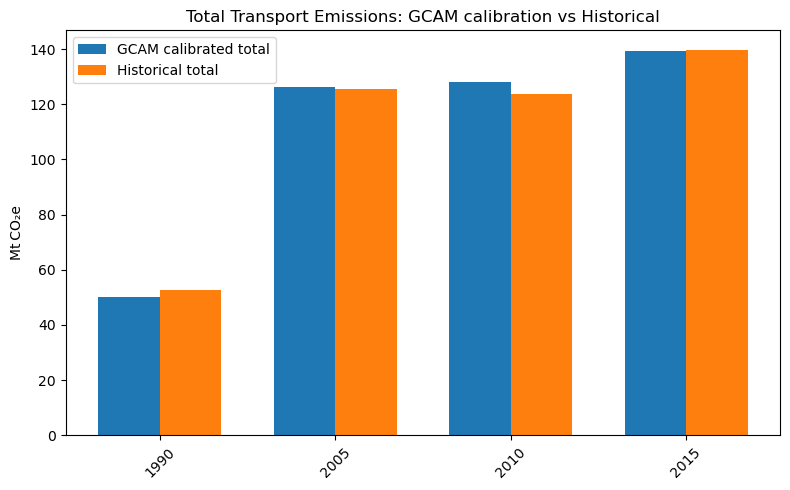

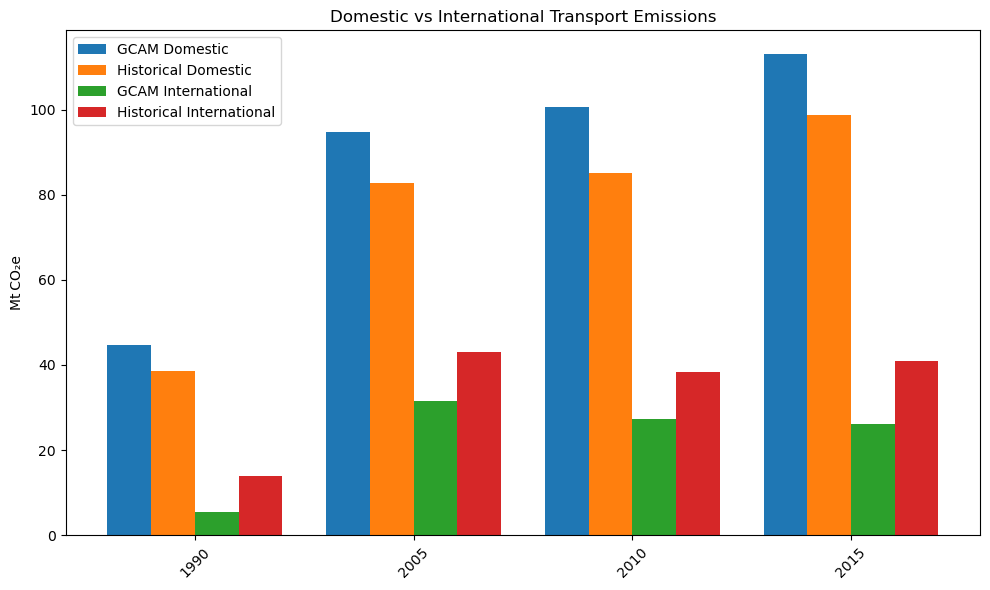

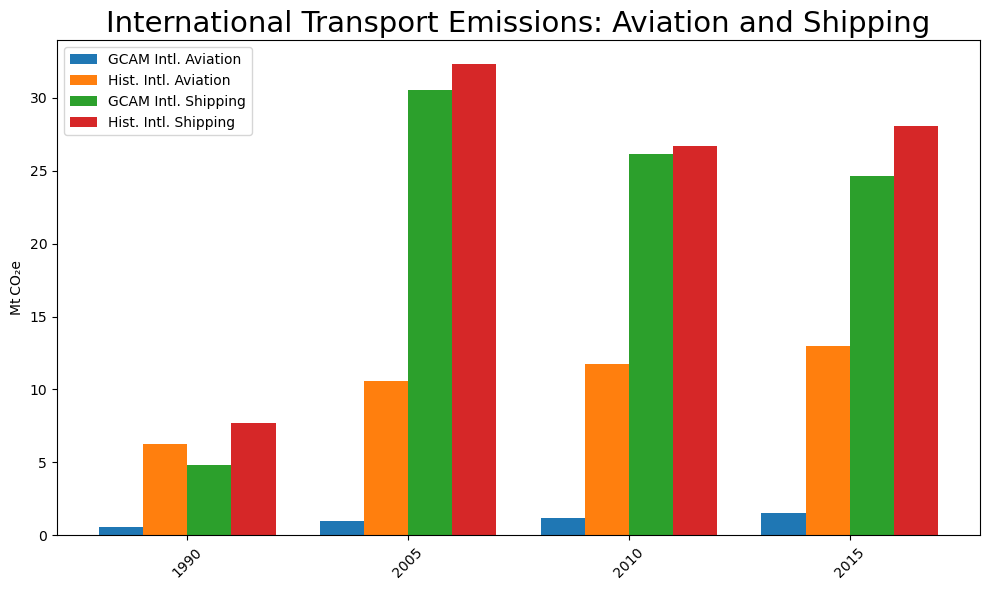

In [37]:


# ---- 1. TOTAL comparison (GCAM vs Historical) ----
fig1, ax1 = plt.subplots(figsize=(8, 5))

bar_width = 0.35
idx = np.arange(len(years))

gcam_total = gcam_dom + gcam_intl
hist_total = hist_dom + hist_intl

ax1.bar(idx, gcam_total, bar_width, label="GCAM calibrated total")
ax1.bar(idx + bar_width, hist_total, bar_width, label="Historical total")

ax1.set_xticks(idx + bar_width / 2)
ax1.set_xticklabels(years)
ax1.set_ylabel("Mt CO₂e")
ax1.set_title("Total Transport Emissions: GCAM calibration vs Historical")
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()

# ---- 2. Component comparison (Domestic & International) ----
fig2, ax2 = plt.subplots(figsize=(10, 6))

bar_width = 0.2
idx = np.arange(len(years))

ax2.bar(idx - bar_width, gcam_dom, bar_width, label="GCAM Domestic")
ax2.bar(idx, hist_dom, bar_width, label="Historical Domestic")
ax2.bar(idx + bar_width, gcam_intl, bar_width, label="GCAM International")
ax2.bar(idx + 2*bar_width, hist_intl, bar_width, label="Historical International")

ax2.set_xticks(idx + bar_width / 2)
ax2.set_xticklabels(years)
ax2.set_ylabel("Mt CO₂e")
ax2.set_title("Domestic vs International Transport Emissions")
ax2.legend()
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()

# ---- 2. Component comparison (Domestic & International) ----
fig2, ax2 = plt.subplots(figsize=(10, 6))

bar_width = 0.2
idx = np.arange(len(years))

ax2.bar(idx - bar_width, gcam_intl_avi, bar_width, label="GCAM Intl. Aviation")
ax2.bar(idx, hist_intl_avi, bar_width, label="Hist. Intl. Aviation")
ax2.bar(idx + bar_width, gcam_intl_ship, bar_width, label="GCAM Intl. Shipping")
ax2.bar(idx + 2*bar_width, hist_intl_ship, bar_width, label="Hist. Intl. Shipping")

ax2.set_xticks(idx + bar_width / 2)
ax2.set_xticklabels(years)
ax2.set_ylabel("Mt CO₂e")
ax2.set_title("International Transport Emissions: Aviation and Shipping", fontsize=21)
ax2.legend()
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()

plt.show()

In [40]:
dfEmissHist2 = pd.read_excel("./extdata/emiss_trn_korea.xlsx", sheet_name="Sheet2", index_col=0)[years]
dfEmissHist2

,1990,2005,2010,2015
GIR (2020),,,,
a. domestic aviation,837.040000,1039.740000,1138.090000,1456.290000
b. domestic shipping,2441.200000,2775.250000,2268.900000,1639.740000
c. International Aviation,6244.070000,10603.920000,11718.920000,12962.150000
d. International Shipping,7703.110000,32333.720000,26725.370000,28075.080000
A. Aviation Total,7081.110000,11643.660000,12857.010000,14418.440000
B. Domestic Avi. Share,0.118207,0.089297,0.088519,0.101002
C. Shipping Total,10144.310000,35108.970000,28994.270000,29714.820000
D. Domestic Ship. Share,0.240647,0.079047,0.078253,0.055183
E. Total,17225.420000,46752.630000,41851.280000,44133.260000


In [42]:
gcam_dom_avi = dfEmissHist2.loc['x. domestic aviation'] / 1000
gcam_intl_avi = dfEmissHist2.loc['z. International Aviation'] / 1000

# Historical values (Mt CO₂e)
hist_dom_avi = dfEmissHist2.loc['a. domestic aviation'] / 1000
hist_intl_avi = dfEmissHist2.loc['c. International Aviation'] / 1000

gcam_dom_ship = dfEmissHist2.loc['y. domestic shipping'] / 1000
gcam_intl_ship = dfEmissHist2.loc['w. International Shipping'] / 1000

# Historical values (Mt CO₂e)
hist_dom_ship = dfEmissHist2.loc['b. domestic shipping'] / 1000
hist_intl_ship = dfEmissHist2.loc['d. International Shipping'] / 1000
print(gcam_intl_ship)

1990     4.835276
2005    30.555450
2010    26.229209
2015    24.740890
Name: w. International Shipping, dtype: float64


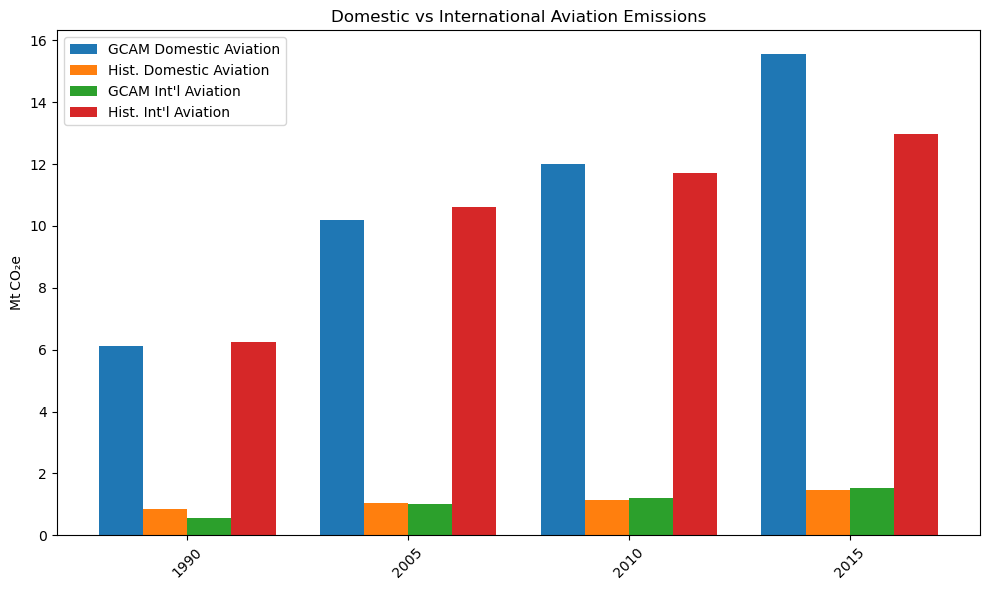

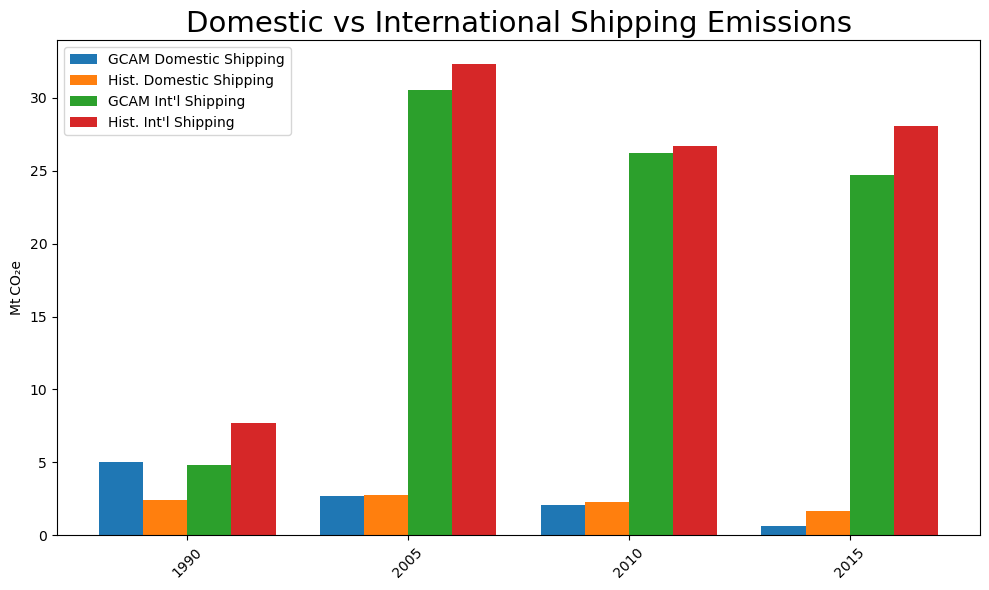

In [43]:


# # ---- 1. TOTAL comparison (GCAM vs Historical) ----
# fig1, ax1 = plt.subplots(figsize=(8, 5))

# bar_width = 0.35
# idx = np.arange(len(years))

# gcam_total = gcam_dom + gcam_intl
# hist_total = hist_dom + hist_intl

# ax1.bar(idx, gcam_total, bar_width, label="GCAM calibrated total")
# ax1.bar(idx + bar_width, hist_total, bar_width, label="Historical total")

# ax1.set_xticks(idx + bar_width / 2)
# ax1.set_xticklabels(years)
# ax1.set_ylabel("Mt CO₂e")
# ax1.set_title("Total Transport Emissions: GCAM calibration vs Historical")
# ax1.legend()
# ax1.tick_params(axis='x', rotation=45)
# plt.tight_layout()

# ---- 2. Component comparison (Domestic & International) ----
fig2, ax2 = plt.subplots(figsize=(10, 6))

bar_width = 0.2
idx = np.arange(len(years))

ax2.bar(idx - bar_width, gcam_dom_avi, bar_width, label="GCAM Domestic Aviation")
ax2.bar(idx, hist_dom_avi, bar_width, label="Hist. Domestic Aviation")
ax2.bar(idx + bar_width, gcam_intl_avi, bar_width, label="GCAM Int'l Aviation")
ax2.bar(idx + 2*bar_width, hist_intl_avi, bar_width, label="Hist. Int'l Aviation")

ax2.set_xticks(idx + bar_width / 2)
ax2.set_xticklabels(years)
ax2.set_ylabel("Mt CO₂e")
ax2.set_title("Domestic vs International Aviation Emissions")
ax2.legend()
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()

# ---- 2. Component comparison (Domestic & International) ----
fig2, ax2 = plt.subplots(figsize=(10, 6))

bar_width = 0.2
idx = np.arange(len(years))

ax2.bar(idx - bar_width, gcam_dom_ship, bar_width, label="GCAM Domestic Shipping")
ax2.bar(idx, hist_dom_ship, bar_width, label="Hist. Domestic Shipping")
ax2.bar(idx + bar_width, gcam_intl_ship, bar_width, label="GCAM Int'l Shipping")
ax2.bar(idx + 2*bar_width, hist_intl_ship, bar_width, label="Hist. Int'l Shipping")

ax2.set_xticks(idx + bar_width / 2)
ax2.set_xticklabels(years)
ax2.set_ylabel("Mt CO₂e")
ax2.set_title("Domestic vs International Shipping Emissions", fontsize=21)
ax2.legend()
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()

plt.show()